In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_absolute_error

df = pd.read_csv("../data/deliverys_data.csv", encoding="latin1")

df.head(5)





,distance_km,maps_eta_minutes,hour_of_day,day_of_week,actual_delivery_minutes
0,19.30,30.11,5,2,50.83
1,24.02,34.37,4,1,35.68
2,9.98,16.32,0,1,22.23
3,28.94,50.76,17,0,85.43
4,26.11,41.50,2,1,45.72


In [41]:
# all the columns except the target
X = df.drop('actual_delivery_minutes', axis=1)

y = df['actual_delivery_minutes']

In [42]:
y

0       50.83
1       35.68
2       22.23
3       85.43
4       45.72
        ...  
4995    18.89
4996    90.17
4997    23.30
4998    34.76
4999    45.72
Name: actual_delivery_minutes, Length: 5000, dtype: float64

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_absolute_error

df = pd.read_csv("../data/deliverys_data.csv", encoding="latin1")

df.head(5)





X = df.drop('actual_delivery_minutes', axis=1)

y = df['actual_delivery_minutes']
#x_train is the training features and y_train is the training target
#x_test is the testing features and y_test is the testing target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)
X_test.to_csv('../data/test_set_X.csv', index=False)
y_test.to_csv('../data/test_set_y.csv', index=False)
print(X_test.shape, y_test.shape)

(1000, 4) (1000,)


In [45]:
#we predict the delivery time in minutes (numbers)
from sklearn.ensemble import RandomForestRegressor


In [46]:
rf=RandomForestRegressor()

In [47]:
#the model is trained here
rf.fit(X_train, y_train)

RandomForestRegressor()

In [48]:
y_pred=rf.predict(X_test)


In [49]:
#the model score is checked here
model_score=rf.score(X_test, y_test)
print (model_score)

0.8975596603354051


In [50]:
#check the average error of the model in minutes
print(mean_absolute_error(y_test, y_pred))


8.368659000000003


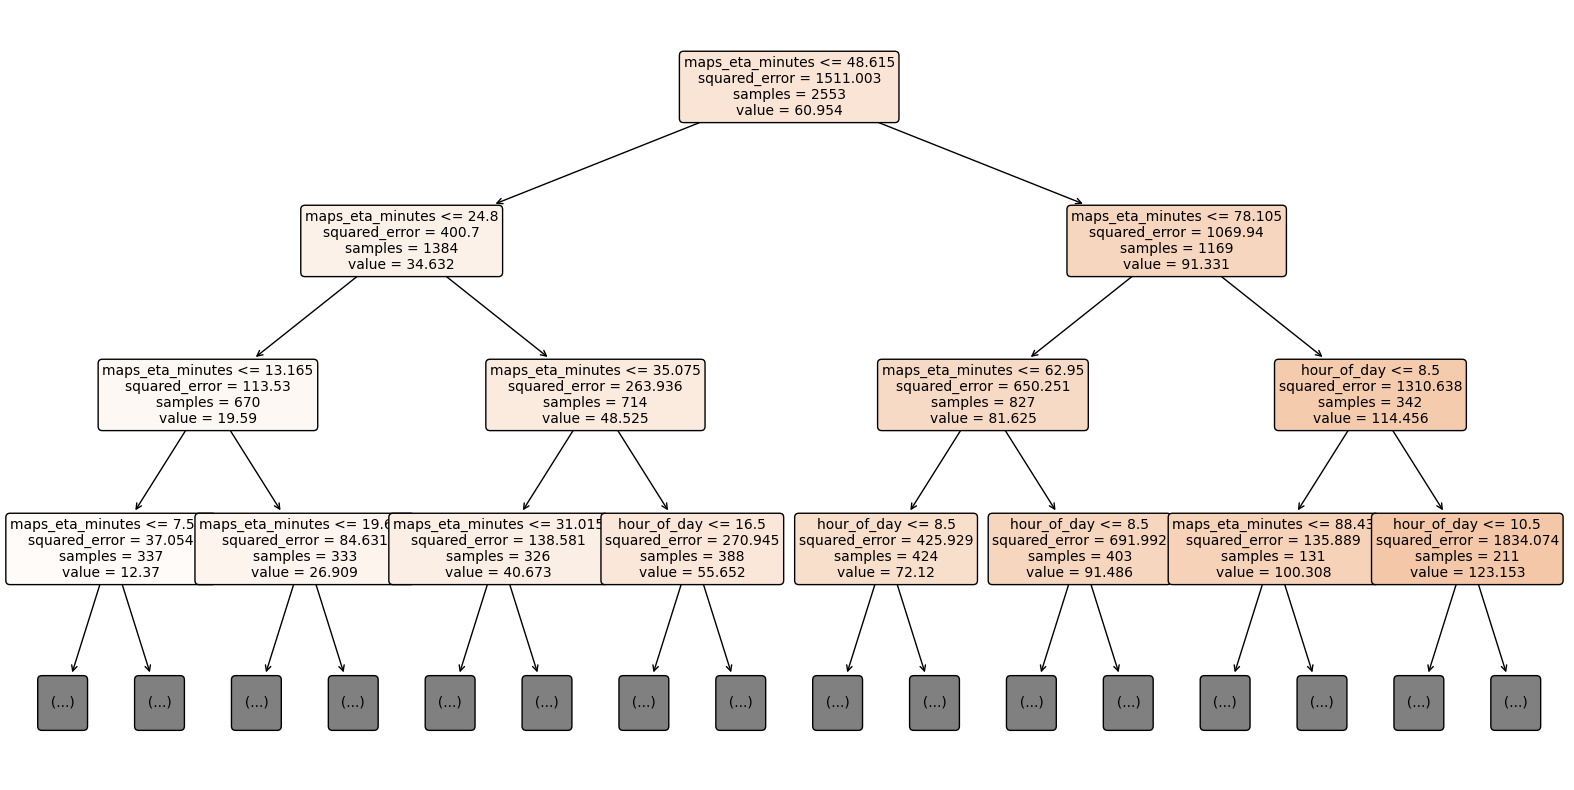

In [51]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

#set the figure size to make it readable
plt.figure(figsize=(20,10))


plot_tree(rf.estimators_[0], 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          max_depth=3,
          fontsize=10)

plt.show()

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_absolute_error

df = pd.read_csv("../data/deliverys_data.csv", encoding="latin1")

df.head(5)
#all the columns  except the target which is 'actual_delivery_minutes' 
X = df.drop('actual_delivery_minutes', axis=1)
#the target column 
y = df['actual_delivery_minutes']
#split the data to training and testing sets to 20% test size and 80% training size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

rf=RandomForestRegressor()
#train rf
rf.fit(X_train, y_train) 
y_pred=rf.predict(X_test)
rf.score(X_test, y_test)
#calculate and print the mean absolute error
print(mean_absolute_error(y_test, y_pred))




8.370954800000003


In [53]:
import joblib

#take the trained model (which is stored in the variable rf)
#and save it to the path we defined in our architecture
joblib.dump(rf, '../artifacts/eta_predictor_model.joblib')

print("Model saved successfully!")
print("File location: backend/ML/artifacts/eta_predictor_model.joblib")

Model saved successfully!
File location: backend/ML/artifacts/eta_predictor_model.joblib


In [54]:
import joblib
import pandas as pd

#load the model
print("Loading the saved model...")
loaded_model = joblib.load('../artifacts/eta_predictor_model.joblib')
print("Model loaded successfully!")

#example new delivery data
new_delivery_data = {
    'distance_km': 25.5,
    'maps_eta_minutes': 38.0,
    'hour_of_day': 17,  # Afternoon hour, expected traffic
    'day_of_week': 1    
}

#make it a DataFrame
single_delivery = pd.DataFrame([new_delivery_data])

#asking for a prediction from the loaded model
prediction = loaded_model.predict(single_delivery)

print("\n--- New Delivery Prediction ---")
print(f"Data: {new_delivery_data}")
#predicted value, formatted to two decimal places.
print(f"Predicted ETA: {prediction[0]:.2f} minutes")

Loading the saved model...
Model loaded successfully!

--- New Delivery Prediction ---
Data: {'distance_km': 25.5, 'maps_eta_minutes': 38.0, 'hour_of_day': 17, 'day_of_week': 1}
Predicted ETA: 87.74 minutes
